# DocSem 실제 데이터 탐색

이 Notebook은 DocSem의 `user_query`, 정답 `answer`, 근거 `evidence`를 결합하고 PDF 페이지를 이미지로 렌더링해 인스턴스 단위로 확인합니다. 공개 train 라벨만 사용하며 validation 정답은 다루지 않습니다.

## 1. 환경과 데이터 경로

In [1]:
import json
import math
import os
import re
import textwrap
import warnings
from pathlib import Path

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import pandas as pd
import pymupdf
from huggingface_hub import hf_hub_download, snapshot_download
from IPython.display import Markdown, display
from PIL import Image

REPO_ID = "amitbcp/docinsights-2026-shared-task-data"
REVISION = "b171c5ad488f0c8c50df05951a5b288ea50e9501"
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data/raw/docsem"
RANDOM_STATE = 42

pd.set_option("display.max_colwidth", 160)
print(f"데이터 디렉터리: {DATA_DIR.relative_to(PROJECT_ROOT)}")

데이터 디렉터리: data/raw/docsem


## 2. Manifest와 train 정답 로드

우선 용량이 작은 JSONL만 받습니다. PDF는 아래의 인스턴스 탐색 함수가 실제로 필요한 파일만 내려받습니다.

In [2]:
MANIFEST_PATTERNS = [
    "train/tasks.jsonl",
    "train/labels.jsonl",
    "val/tasks.jsonl",
]

snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    revision=REVISION,
    local_dir=DATA_DIR,
    allow_patterns=MANIFEST_PATTERNS,
)

def load_jsonl(path):
    with Path(path).open(encoding="utf-8") as file:
        return pd.DataFrame(json.loads(line) for line in file if line.strip())

train_tasks = load_jsonl(DATA_DIR / "train/tasks.jsonl")
train_labels = load_jsonl(DATA_DIR / "train/labels.jsonl")
validation_tasks = load_jsonl(DATA_DIR / "val/tasks.jsonl")
train = train_tasks.merge(train_labels, on="instance_id", how="inner", validate="one_to_one")

assert len(train) == len(train_tasks) == len(train_labels), "train task와 label이 일대일로 대응하지 않습니다."
assert set(train_tasks.instance_id).isdisjoint(validation_tasks.instance_id), "train과 validation ID가 겹칩니다."

display(pd.DataFrame({"split": ["train", "validation"], "tasks": [len(train), len(validation_tasks)], "public_answers": [len(train_labels), 0]}))

,split,tasks,public_answers
0,train,908,908
1,validation,217,0


## 3. 실제 Query와 정답 확인

In [3]:
train["query_characters"] = train.user_query.str.len()
train["query_words"] = train.user_query.str.split().str.len()
train["evidence_count"] = train.evidence.str.len()
train["answer_number"] = pd.to_numeric(train.answer.str.replace(",", ""), errors="coerce")

display(train[["instance_id", "user_query", "answer", "evidence", "document_pdf"]].head(12))
display(train[["query_characters", "query_words", "evidence_count", "answer_number"]].describe().round(2))
display(train.answer.value_counts().head(20).rename_axis("answer").reset_index(name="count"))

,instance_id,user_query,answer,evidence,document_pdf
0,task_000001,"According to the brief's quantitative scenario concerning percentage and foot, what final value is required?",10,[b10],train/documents/task_000001.pdf
1,task_000002,"According to the brief's quantitative scenario concerning percentage and foot, what final value is required?",20,[b06],train/documents/task_000002.pdf
2,task_000003,Use the relevant quantitative passage in this document to determine the outcome concerning rolling and city.,140,[b10],train/documents/task_000003.pdf
3,task_000004,What is the requested result for the report's scenario about dense and starts?,140,[b12],train/documents/task_000004.pdf
4,task_000005,"According to the brief's quantitative scenario concerning whale and feet, what final value is required?",20,[b09],train/documents/task_000005.pdf
5,task_000006,Use the relevant quantitative passage in this document to determine the outcome concerning difference and probability.,25,[b07],train/documents/task_000006.pdf
6,task_000007,"According to the brief's quantitative scenario concerning difference and probability, what final value is required?",25,[b10],train/documents/task_000007.pdf
7,task_000008,Use the relevant quantitative passage in this document to determine the outcome concerning tossing and six-sided.,25,[b13],train/documents/task_000008.pdf
8,task_000009,What is the requested result for the report's scenario about whale and measuring?,5,[b09],train/documents/task_000009.pdf
9,task_000010,What is the requested result for the report's scenario about company and employees?,25,[b11],train/documents/task_000010.pdf


,query_characters,query_words,evidence_count,answer_number
count,908.00,908.00,908.0,908.00
mean,98.48,14.70,1.0,967.98
std,13.83,1.25,0.0,4451.67
min,75.00,13.00,1.0,1.00
25%,81.00,13.00,1.0,22.00
50%,106.00,15.00,1.0,63.00
75%,109.00,16.00,1.0,222.25
max,119.00,16.00,1.0,43200.00


,answer,count
0,50,26
1,5,23
2,100,21
3,8,19
4,2,18
5,4,18
6,6,18
7,12,16
8,25,15
9,9,15


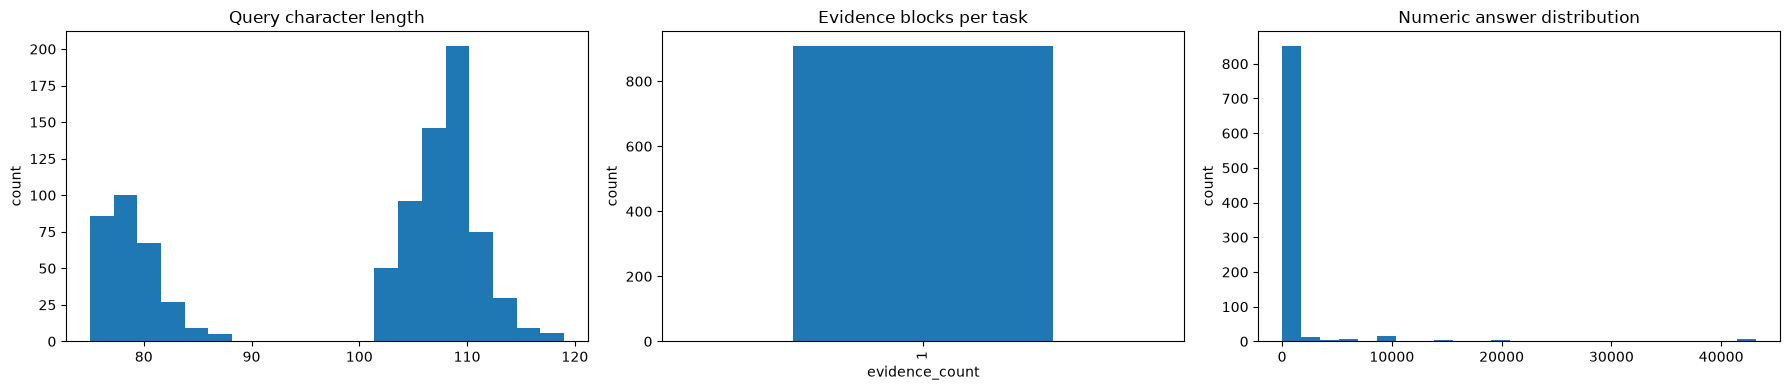

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
train.query_characters.plot.hist(bins=20, ax=axes[0], title="Query character length")
train.evidence_count.value_counts().sort_index().plot.bar(ax=axes[1], title="Evidence blocks per task")
train.answer_number.plot.hist(bins=25, ax=axes[2], title="Numeric answer distribution")
for axis in axes:
    axis.set_ylabel("count")
plt.tight_layout()
plt.show()

## 4. 인스턴스 단위 PDF 이미지·Query·정답·Evidence 탐색

`inspect_instance()`는 선택한 train 인스턴스의 PDF만 내려받고 모든 페이지를 이미지로 렌더링합니다. 또한 PDF 텍스트에서 정답 근거 block ID가 포함된 줄을 찾아 함께 보여줍니다.

In [5]:
train_by_id = train.set_index("instance_id", drop=False)

def ensure_pdf(document_pdf):
    local_path = DATA_DIR / document_pdf
    if local_path.is_file():
        return local_path
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        revision=REVISION,
        filename=document_pdf,
        local_dir=DATA_DIR,
    )
    return Path(downloaded)

def page_to_image(page, dpi=130):
    pixmap = page.get_pixmap(dpi=dpi, alpha=False)
    return Image.frombytes("RGB", (pixmap.width, pixmap.height), pixmap.samples)

def find_evidence_snippets(document, evidence_ids):
    snippets = []
    for page_number, page in enumerate(document, start=1):
        lines = [line.strip() for line in page.get_text("text").splitlines() if line.strip()]
        for evidence_id in evidence_ids:
            pattern = re.compile(rf"^{re.escape(evidence_id)}\s*:", re.IGNORECASE)
            for line_index, line in enumerate(lines):
                if pattern.search(line):
                    snippets.append({"page": page_number, "evidence": evidence_id, "text": " ".join(lines[line_index:line_index + 3])})
                    break
    return snippets

def inspect_instance(instance_id, dpi=130):
    if instance_id not in train_by_id.index:
        raise KeyError(f"공개 정답이 있는 train instance가 아닙니다: {instance_id}")
    row = train_by_id.loc[instance_id]
    pdf_path = ensure_pdf(row.document_pdf)
    display(Markdown(f"### `{instance_id}`\n\n- **Query:** {row.user_query}\n- **Answer:** `{row.answer}`\n- **Evidence:** `{', '.join(row.evidence)}`\n- **PDF:** `{row.document_pdf}`"))
    with pymupdf.open(pdf_path) as document:
        snippets = find_evidence_snippets(document, row.evidence)
        if snippets:
            display(pd.DataFrame(snippets))
        else:
            display(Markdown("_텍스트 레이어에서 evidence block을 찾지 못했습니다. 페이지 이미지의 가시 block ID를 확인하세요._"))
        images = [page_to_image(page, dpi=dpi) for page in document]
    fig, axes = plt.subplots(len(images), 1, figsize=(14, 10 * len(images)))
    axes = [axes] if len(images) == 1 else list(axes)
    for page_number, (axis, image) in enumerate(zip(axes, images, strict=True), start=1):
        axis.imshow(image)
        axis.set_title(f"{instance_id} · page {page_number}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()
    return row

### `task_000001`

- **Query:** According to the brief's quantitative scenario concerning percentage and foot, what final value is required?
- **Answer:** `10`
- **Evidence:** `b10`
- **PDF:** `train/documents/task_000001.pdf`

_텍스트 레이어에서 evidence block을 찾지 못했습니다. 페이지 이미지의 가시 block ID를 확인하세요._

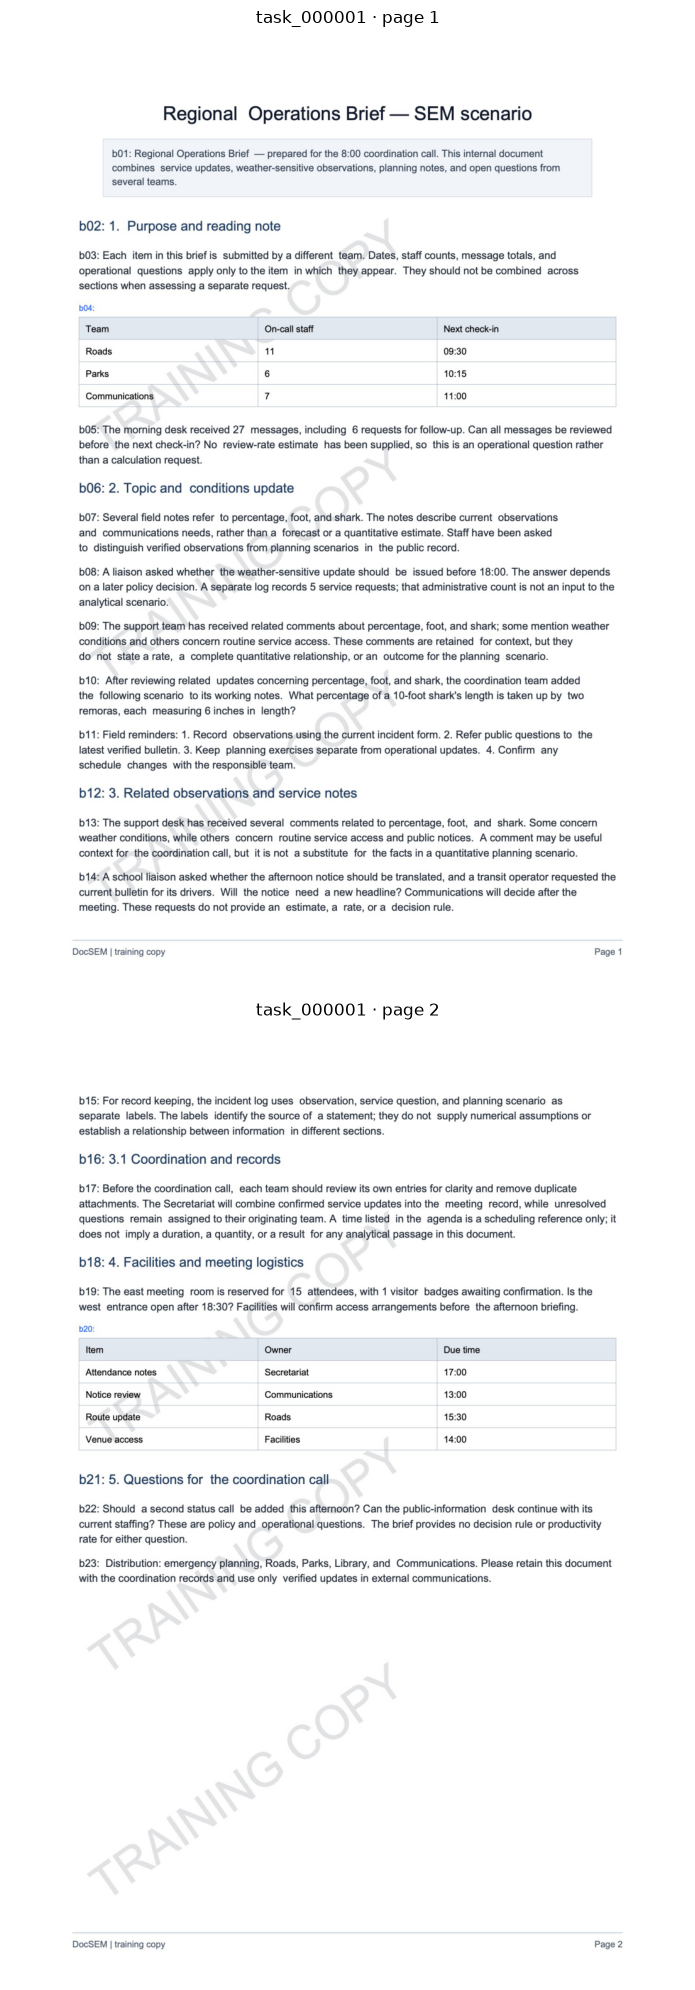

In [6]:
INSTANCE_ID = "task_000001"
selected_instance = inspect_instance(INSTANCE_ID)

### 예시 해석: `task_000001`

- **PDF 구조:** A4 2페이지 문서이며 각 내용 단락과 표에 `b01`부터 `b23`까지 block ID가 붙어 있습니다.
- **Evidence 확인:** 공개 label의 `evidence`는 `b10`입니다. 1페이지에서 `b10:`으로 시작하는 단락이 정답 계산에 필요한 근거이고, 나머지 block은 문맥 또는 방해 정보입니다.
- **근거 내용:** 길이가 10 foot인 shark에 길이 6 inch인 remora 두 마리가 붙어 있을 때 remora가 차지하는 비율을 묻습니다.
- **계산:** `6 inch × 2 = 12 inch = 1 foot`, `1 foot ÷ 10 foot × 100 = 10%`입니다.
- **정답 연결:** 공개 `answer` 값 `10`은 계산한 `10%`의 수치 부분이며, 이 계산을 직접 뒷받침하는 block이 `b10`입니다.

## 5. 여러 인스턴스의 이미지·Query·정답 비교

무작위 train 표본의 첫 페이지를 같은 화면에서 비교합니다. `sample_size`와 `random_state`를 바꿔 다른 Query, 정답, evidence 사례를 탐색할 수 있습니다.

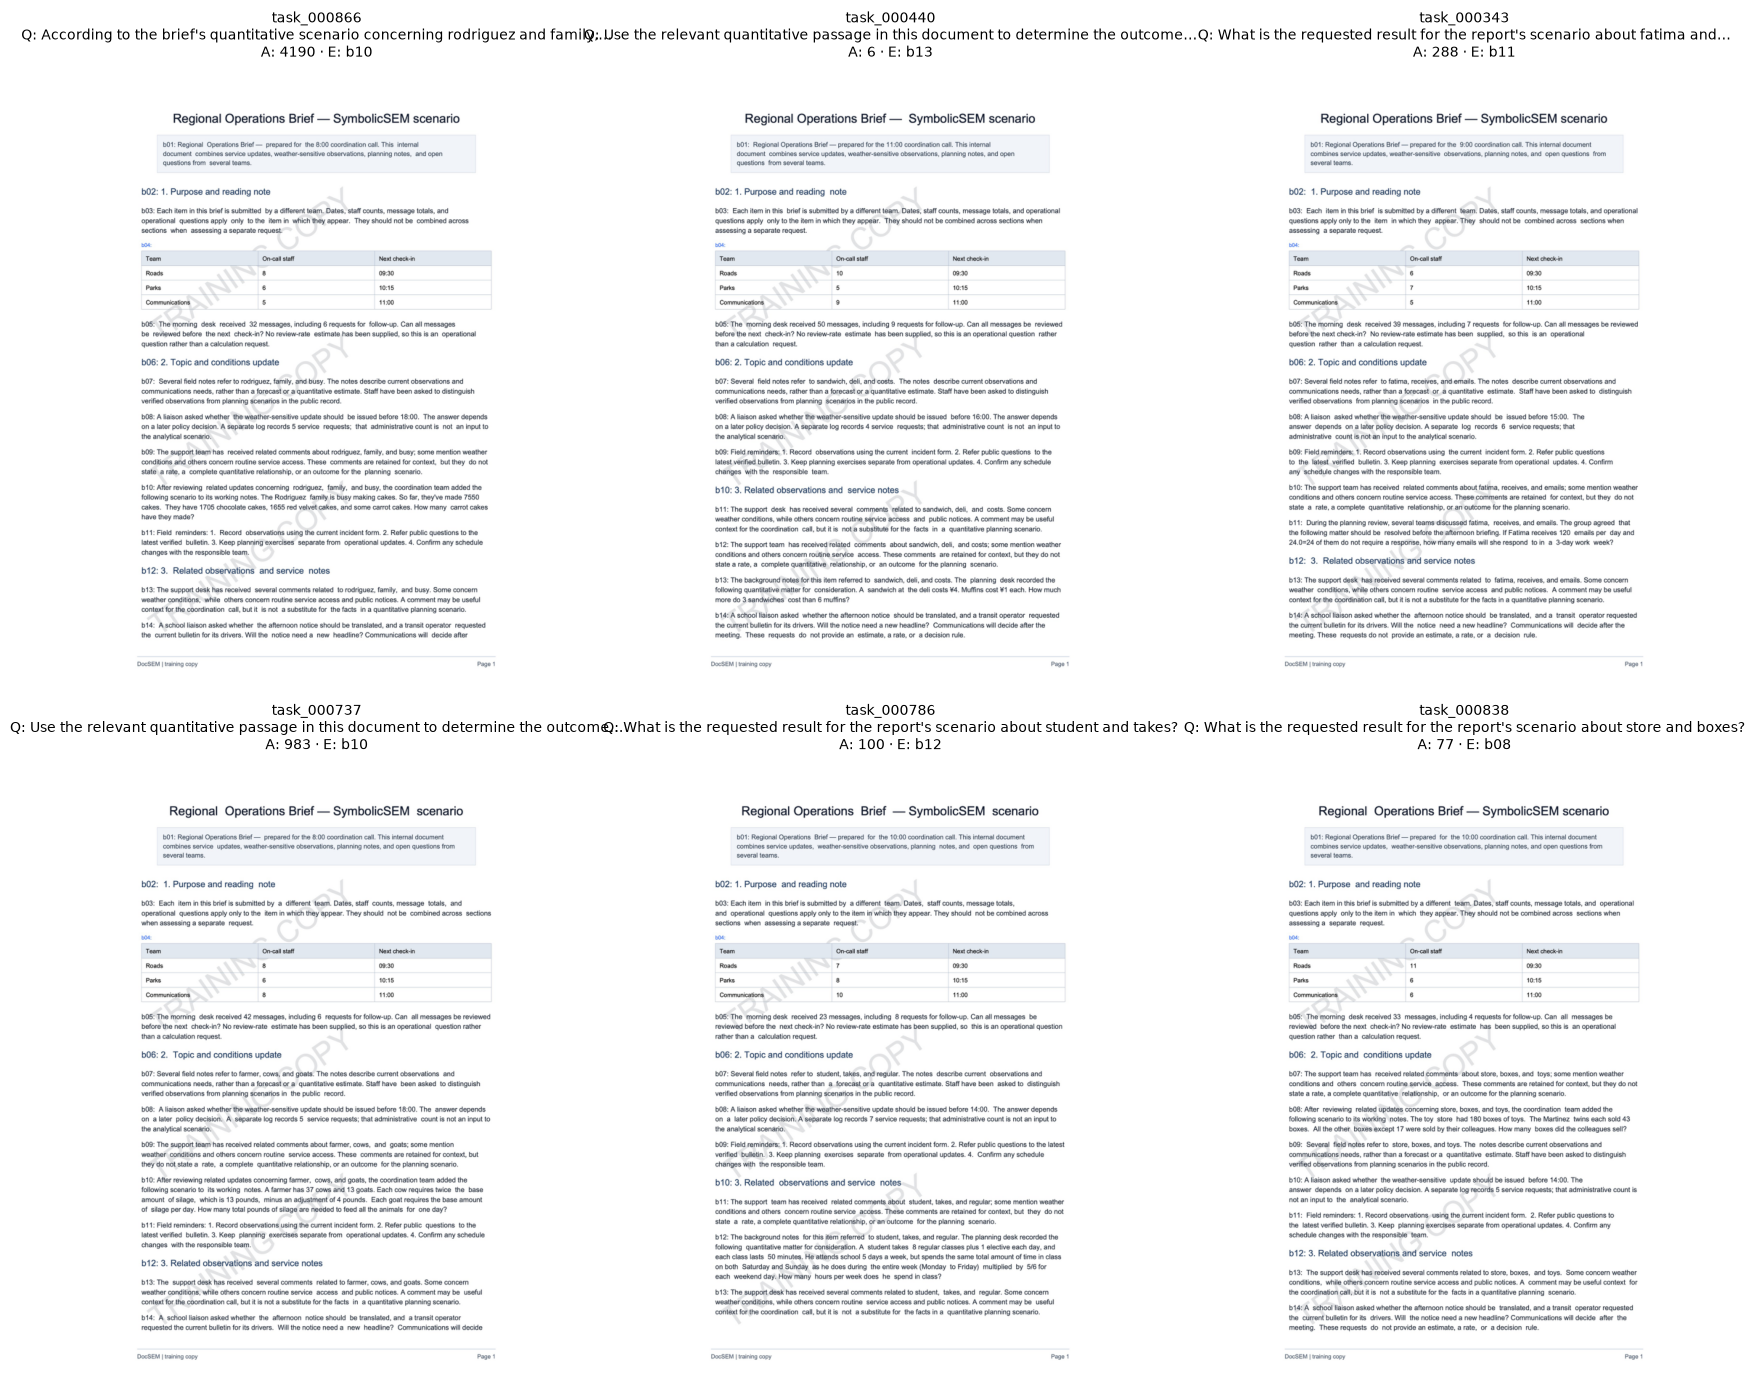

,instance_id,user_query,answer,evidence,document_pdf
865,task_000866,"According to the brief's quantitative scenario concerning rodriguez and family, what final value is required?",4190,[b10],train/documents/task_000866.pdf
439,task_000440,Use the relevant quantitative passage in this document to determine the outcome concerning sandwich and deli.,6,[b13],train/documents/task_000440.pdf
342,task_000343,What is the requested result for the report's scenario about fatima and receives?,288,[b11],train/documents/task_000343.pdf
736,task_000737,Use the relevant quantitative passage in this document to determine the outcome concerning farmer and cows.,983,[b10],train/documents/task_000737.pdf
785,task_000786,What is the requested result for the report's scenario about student and takes?,100,[b12],train/documents/task_000786.pdf
837,task_000838,What is the requested result for the report's scenario about store and boxes?,77,[b08],train/documents/task_000838.pdf


In [7]:
def compare_sample(sample_size=6, random_state=RANDOM_STATE, dpi=90):
    sample = train.sample(n=min(sample_size, len(train)), random_state=random_state)
    columns = 3
    rows = math.ceil(len(sample) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(18, 7 * rows))
    axes = list(axes.ravel())
    for axis, (_, item) in zip(axes, sample.iterrows(), strict=False):
        pdf_path = ensure_pdf(item.document_pdf)
        with pymupdf.open(pdf_path) as document:
            image = page_to_image(document[0], dpi=dpi)
        query = textwrap.shorten(item.user_query, width=80, placeholder="…")
        evidence = ", ".join(item.evidence)
        axis.imshow(image)
        axis.set_title(f"{item.instance_id}\nQ: {query}\nA: {item.answer} · E: {evidence}", fontsize=10)
        axis.axis("off")
    for axis in axes[len(sample):]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()
    return sample[["instance_id", "user_query", "answer", "evidence", "document_pdf"]]

sample_instances = compare_sample(sample_size=6)
display(sample_instances)

## 다음 분석 질문

- 같은 Query 템플릿이 서로 다른 문서와 정답에 어떻게 대응하는가?
- evidence block은 문서의 어느 위치와 페이지에 주로 나타나는가?
- 큰 값, 작은 값, 여러 evidence block을 요구하는 사례에서 시각적 구조가 어떻게 다른가?
- 표, 문단, 목록 등 근거 표현 유형별로 별도의 풀이 전략이 필요한가?